In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go

## Mini-Lab: Plotly basics

In this lab you will briefly learn how to work with both the express and graph_objects APIs of **Plotly**. You will be working with data on weekly influenza incidence.

In [3]:
flu = pd.read_csv("./data/influenza_weekly.csv")
flu.head()

/var/folders/53/qn2bqxzd489fdf7zn6smrbtw0000gn/T/ipykernel_29986/792316442.py:1: DtypeWarning: Columns (21) have mixed types. Specify dtype option on import or set low_memory=False.
  flu = pd.read_csv("./data/influenza_weekly.csv")


,REPORT_ID,Country,WHOREGION,FLUREGION,Year,Week,SDATE,EDATE,SPEC_RECEIVED_NB,SPEC_PROCESSED_NB,...,AH5,ANOTSUBTYPED,INF_A,BYAMAGATA,BVICTORIA,BNOTDETERMINED,INF_B,ALL_INF,ALL_INF2,TITLE
0,1048,Afghanistan,Eastern Mediterranean Region of WHO,Southern Asia,2015,5,2015-01-26,2015-02-01,43.0,43.0,...,0.0,0.0,1,0.0,3.0,0.0,3,4,NaN,Sporadic
1,1059,Afghanistan,Eastern Mediterranean Region of WHO,Southern Asia,2015,16,2015-04-13,2015-04-19,22.0,22.0,...,0.0,0.0,1,0.0,0.0,0.0,0,1,NaN,Sporadic
2,1060,Afghanistan,Eastern Mediterranean Region of WHO,Southern Asia,2015,17,2015-04-20,2015-04-26,26.0,26.0,...,0.0,0.0,1,0.0,0.0,0.0,0,1,NaN,Sporadic
3,1061,Afghanistan,Eastern Mediterranean Region of WHO,Southern Asia,2015,18,2015-04-27,2015-05-03,17.0,17.0,...,0.0,0.0,0,0.0,0.0,0.0,0,0,NaN,Sporadic
4,1062,Afghanistan,Eastern Mediterranean Region of WHO,Southern Asia,2015,19,2015-05-04,2015-05-10,23.0,23.0,...,0.0,0.0,0,0.0,0.0,0.0,0,0,NaN,Sporadic


### Part 1: Bar charts

The express API, as you might infer from its name, provides a quick way to make figures of a certain type with many inferred visual elements. The various ready-built plots you can make with it can be [found here](https://plotly.com/python-api-reference/plotly.express.html).

Using express, create a barchart of all flu cases ("ALL_INF") in the United States by week.

In [5]:
flu['Country'].unique()

array(['Afghanistan', 'Albania', 'Algeria', 'Angola', 'Argentina',
       'Armenia', 'Australia', 'Austria', 'Azerbaijan', 'Bahrain',
       'Bangladesh', 'Belarus', 'Belgium', 'Bhutan',
       'Bosnia and Herzegovina', 'Brazil', 'Bulgaria', 'Burkina Faso',
       'Cambodia', 'Cameroon', 'Central African Republic', 'Chile',
       'China', 'Colombia', 'Congo', "Côte d'Ivoire", 'Croatia',
       'Czechia', 'Democratic Republic of the Congo', 'Denmark',
       'Dominican Republic', 'Ecuador', 'Egypt', 'El Salvador', 'Estonia',
       'Ethiopia', 'Fiji', 'Finland', 'France', 'French Guiana',
       'Georgia', 'Germany', 'Ghana', 'Greece', 'Guadeloupe', 'Guatemala',
       'Honduras', 'Hungary', 'Iceland', 'India', 'Indonesia',
       'Iran (Islamic Republic of)', 'Iraq', 'Ireland', 'Israel', 'Italy',
       'Jamaica', 'Japan', 'Jordan', 'Kazakhstan', 'Kenya', 'Kyrgyzstan',
       "Lao People's Democratic Republic", 'Latvia', 'Lithuania',
       'Luxembourg', 'Madagascar', 'Malaysia', 'Mal

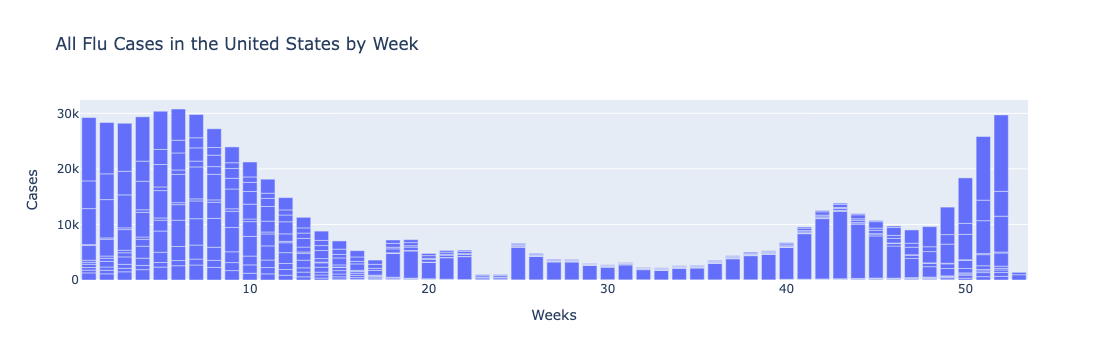

In [10]:
usa = flu[flu['Country'] == 'United States of America']
px.bar(usa, x = 'Week', y = 'ALL_INF', 
       labels = {'Week': 'Weeks', 'ALL_INF': 'Cases'},
       title = 'All Flu Cases in the United States by Week')


Note that plotly subdivides each bar if the granularity of your data is smaller than the granularity of your plotted variables. We have plotted cases by week, but the granularity of the full data is cases by week by year. Each bar subdivision therefore represents a different year. 

Now plot a new barchart of cases by week in the United States, but this time only for 2013, 2014 and 2015. Change the color of the bars by year.

In [20]:
usa['Year'].unique()

array([2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014,
       2015])

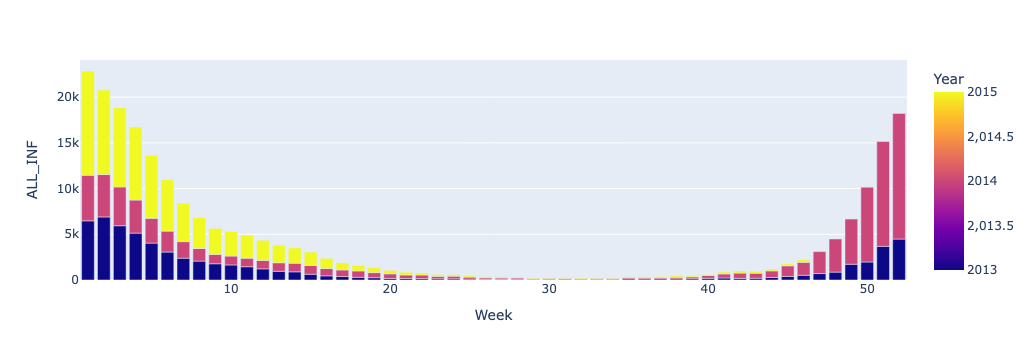

In [23]:
import plotly.graph_objects as go

years = [2013, 2014, 2015]
usa_time = usa[usa['Year'].isin(years)]

px.bar(usa_time, x = 'Week', y = 'ALL_INF', color = 'Year')

The resulting figure may look like a stacked bar chart, but the bars have in fact been overplotted. Create a stacked area chart instead (`px.area()`).

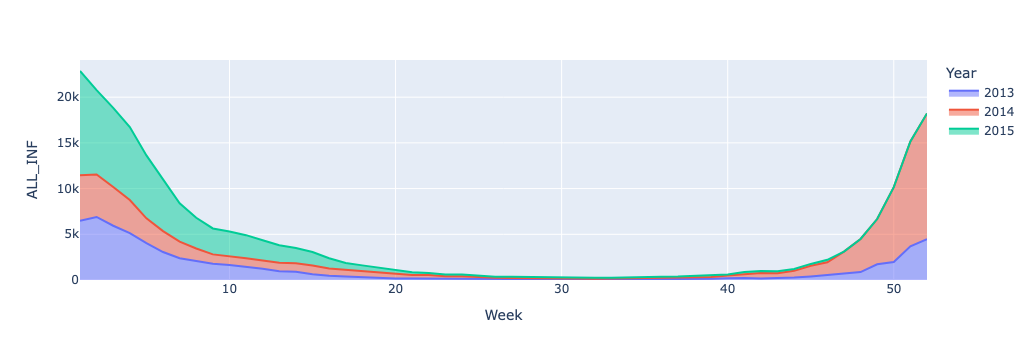

In [24]:
px.area(usa_time, x = 'Week', y = 'ALL_INF', color = 'Year')

Now let's change the color of one of the year's areas. For spot edits, we can access the "traces" that the plot is built from. To do so, you will need to create an object, often called "fig", from your plot. Then use `fig.data` to examine the traces of your area chart. You should see three of them, with a number of properties.

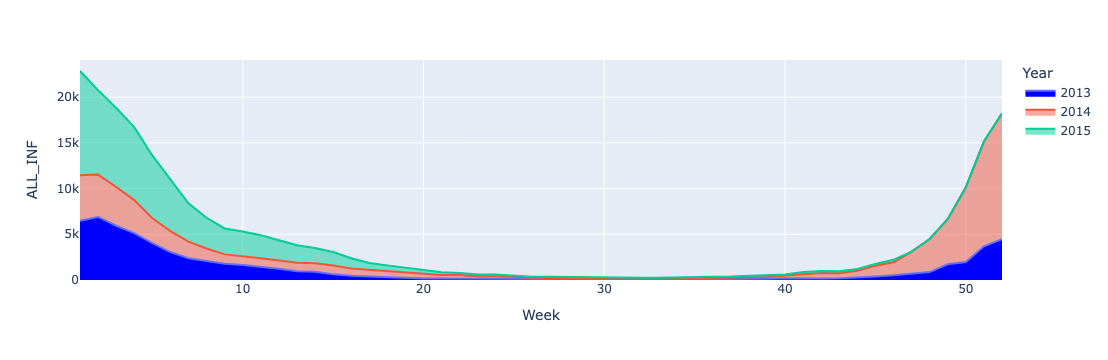

In [38]:
fig = px.area(usa_time, x = 'Week', y = 'ALL_INF', color = 'Year')

# fig.data
# fig.data[0].

fig.data[0].fillcolor = 'blue'
fig

All trace properties can be edited directly by accessing the relevant attribute from the relevant trace. For example, the name of the first trace can be called with `fig.data[0].name`. Replot the figure and change the `fillcolor` of the trace associated with 2014 to something else. All possible attributes for traces are [documented here](https://plotly.com/python/reference/scatter/). 

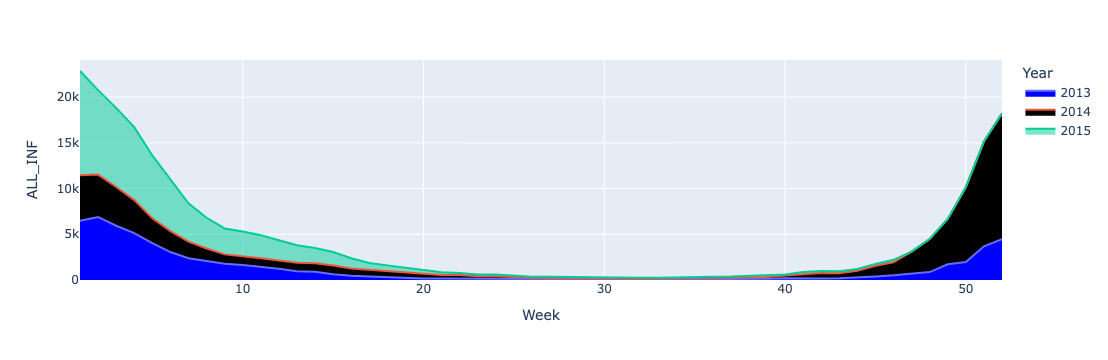

In [42]:
# fig.data[1].name
fig.data[1].fillcolor = 'black'
fig

If we want a greater level of control over the figure, we can build it trace-by-trace using the [graph_objects API](https://plotly.com/python-api-reference/plotly.graph_objects.html#graph-objects). Instatiate a figure object with `go.Figure()`, then use `add_trace()` three times to add a stacked area for each year.

Unintuitively, the relevant trace for an area chart is [go.Scatter](https://plotly.com/python-api-reference/generated/plotly.graph_objects.Scatter.html#plotly.graph_objects.Scatter) with the `stackgroup` argument. 

Add proper labels and change the `width` and `height` of the figure using [.update_layout()](https://plotly.com/python/reference/layout/) (necessary when building plots with graph_objects). 

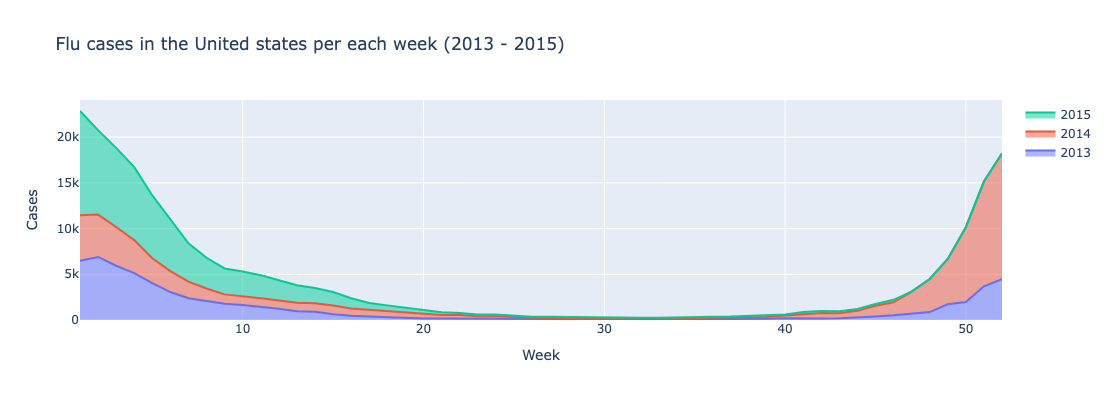

In [50]:
fig = go.Figure()

for year in (years):

    line_year = usa_time[usa_time['Year'] == year]
    fig.add_trace(go.Scatter(x = line_year['Week'], y = line_year['ALL_INF'], name = year, 
                             stackgroup = 'one'))

fig.update_layout(
    title = "Flu cases in the United states per each week (2013 - 2015)",
    xaxis_title = "Week",
    yaxis_title = "Cases",
    showlegend = True,
    width = 700,
    height = 400
)

fig

Explain two things you can learn from your figure.

**Your response**: From looking at the figure, we can see that during the beginning and end of the year (winter season), we have a larger amount of flu cases compared to the rest of the year. In the middle (usually summertime), that's when we have the least amount of cases. We can also see that the cases overall have increased over the years (2015 having exponentially larger amounts of flu cases during the high season compared to 2013). 

### Part 2: 3D Scatterplots

Plotly is particularly useful for plotting 3D figures. Matplotlib also has this functionality, but 3D figures from fixed angles are difficult to interpret.

Subset your flu data for the Eastern Asia, Northern Europe, Southern Africa and North America. Then use `.scatter_3d()` to plot week as your x, year as your y, and influenza cases as your z. Change the color by region and the size based on the amount of Influenza A (INF_A) is present.

3D figures can sometimes be hard to view within your chosen IDE, so you `.write_html()` to write your figure out to file. You can then figure and interact with the figure from your web browser. 

In [52]:
flu['FLUREGION'].unique()

array(['Southern Asia', 'South West Europe', 'Northern Africa',
       'Middle Africa', 'Temperate South America', 'Western Asia',
       'Oceania Melanesia Polynesia', 'Eastern Europe',
       'Tropical South America', 'Western Africa', 'South-East Asia',
       'Eastern Asia', 'Northern Europe', 'Central America and Caribbean',
       'Eastern Africa', 'Central Asia', 'Southern Africa',
       'North America'], dtype=object)

In [54]:
place = ['Eastern Asia', 'Northern Europe', 'Southern Africa', 'North America']

regions = flu[flu['FLUREGION'].isin(place)]

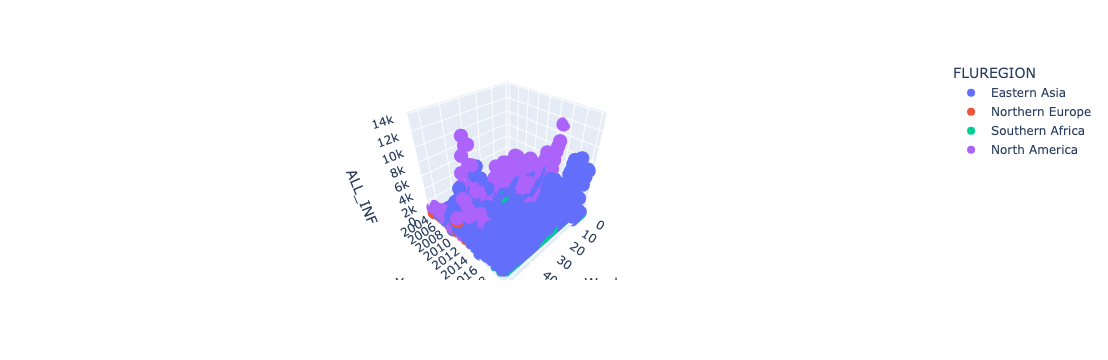

In [64]:
# px.scatter_3d(
#     regions, x = 'Week', y = 'Year', z = 'ALL_INF', color = 'FLUREGION'
# ).write_html('3DPLOT.html')

px.scatter_3d(regions, x = 'Week', y = 'Year', z = 'ALL_INF', color = 'FLUREGION')

Explain three things you can learn from this figure.

**Your response**: After downloading it, we can see that Eastern Asia and North America have a lot more flu cases than the rest of the regions we are comparing. Southern Africa looks to be showing the least, with Northern Europe not being much far from it. We can also see the actual size difference of cases, especially when they peak the highest (towards the beginning and end).

In this lab you learned the core elements of Plotly: using the express API to quickly make interactive figures, using the graph_objects to iteratively add traces to figures and edit their properties directly, and using Plotly's innate 3-dimensional functionality.

Please submit this notebook or your script to the relevant assignment on Canvas. 